In [2]:
!pip install cmdstanpy==1.0.4
!pip install prophet
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.9/73.9 kB 2.3 MB/s eta 0:00:00
  Attempting uninstall: cmdstanpy
    Found existing installation: cmdstanpy 1.3.0
    Uninstalling cmdstanpy-1.3.0:
      Successfully uninstalled cmdstanpy-1.3.0


In [3]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

In [4]:
#Loading ds
dates = pd.date_range(start="2022-01-01", periods=120, freq="W")
np.random.seed(42)
demand = np.random.poisson(lam=200, size=120)


# Creating a DataFrame
df = pd.DataFrame({"ds": dates, "y": demand})

In [5]:
#Feature engineering
df["lag_1"] = df["y"].shift(1)
df["rolling_4"] = df["y"].rolling(window=4).mean()


# Fill NaN values
df.fillna(method="bfill", inplace=True)

/tmp/ipython-input-227320946.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="bfill", inplace=True)


In [6]:
#Prophet model
model = Prophet(weekly_seasonality=True, yearly_seasonality=False)
model.fit(df[["ds", "y"]])


future = model.make_future_dataframe(periods=12, freq="W")
forecast = model.predict(future)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmptl0wd3kj/1jbj0m3_.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmptl0wd3kj/8xzas8ee.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=24449', 'data', 'file=/tmp/tmptl0wd3kj/1jbj0m3_.json', 'init=/tmp/tmptl0wd3kj/8xzas8ee.json', 'output', 'file=/tmp/tmptl0wd3kj/prophet_modelmqxwchpp/prophet_model-20251122045725.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
04:57:25 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:57:25 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [8]:
# detection
threshold = df['y'].mean() + 2 * df['y'].std()
spike_alerts = forecast[forecast['yhat'] > threshold][['ds', 'yhat']]

In [10]:
#Forecasts
forecast_output = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
forecast_output.to_csv("weekly_inventory_forecast.csv", index=False)


print("Forecast generated and saved to weekly_inventory_forecast.csv")
print("Demand Spike Alerts:\n", spike_alerts)

#Outlier Handling
q1 = df['y'].quantile(0.05)
q2 = df['y'].quantile(0.95)
df['y_clean'] = df['y'].clip(lower=q1, upper=q2)


# Refit model with cleaned data
temp_model = Prophet(weekly_seasonality=True)
# Create a temporary dataframe with 'ds' and 'y_clean', then rename 'y_clean' to 'y'
df_cleaned = df[['ds', 'y_clean']].rename(columns={'y_clean': 'y'})
temp_model.fit(df_cleaned)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmptl0wd3kj/ac46hdd3.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmptl0wd3kj/nhgn8sk5.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=95220', 'data', 'file=/tmp/tmptl0wd3kj/ac46hdd3.json', 'init=/tmp/tmptl0wd3kj/nhgn8sk5.json', 'output', 'file=/tmp/tmptl0wd3kj/prophet_modelcw58gt19/prophet_model-20251122045951.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
04:59:51 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


Forecast generated and saved to weekly_inventory_forecast.csv
Demand Spike Alerts:
 Empty DataFrame
Columns: [ds, yhat]
Index: []


04:59:51 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [12]:
#compring original vs forecast
future2 = temp_model.make_future_dataframe(periods=12, freq='W')
forecast2 = temp_model.predict(future2)


comparison_df = forecast[['ds','yhat']].merge(
forecast2[['ds','yhat']].rename(columns={'yhat':'yhat_cleaned'}),
on='ds', how='left'
)
comparison_df.to_csv('forecast_comparison.csv', index=False)

In [13]:
# automation

#"""Simulates an automated pipeline that generates fresh forecasts weekly."""
def generate_rolling_forecast(input_df):
  model = Prophet(weekly_seasonality=True)
  model.fit(input_df[['ds','y']])
  future = model.make_future_dataframe(periods=4, freq='W')
  return model.predict(future)[['ds','yhat']]


rolling_forecast = generate_rolling_forecast(df)
rolling_forecast.to_csv('rolling_forecast.csv', index=False)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmptl0wd3kj/3_i7nhb2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmptl0wd3kj/zf0nd1r_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=81508', 'data', 'file=/tmp/tmptl0wd3kj/3_i7nhb2.json', 'init=/tmp/tmptl0wd3kj/zf0nd1r_.json', 'output', 'file=/tmp/tmptl0wd3kj/prophet_modeljsovcbb5/prophet_model-20251122050159.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
05:01:59 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
05:02:00 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [14]:
#inventory safety check
# Simple logic: Safety stock = average demand + 1.5 * std deviation
safety_stock = df['y'].mean() + 1.5 * df['y'].std()


# Add recommendations to forecast
forecast_output['recommended_safety_stock'] = int(safety_stock)
forecast_output.to_csv('weekly_inventory_forecast.csv', index=False)


print("Extended forecasting pipeline completed.")

Extended forecasting pipeline completed.


/tmp/ipython-input-435185994.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  forecast_output['recommended_safety_stock'] = int(safety_stock)


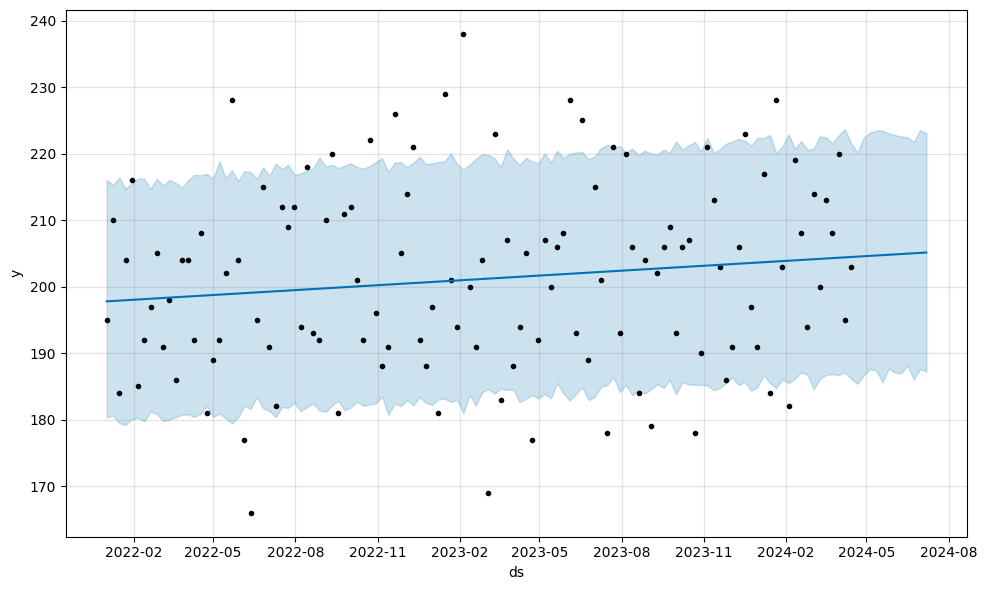

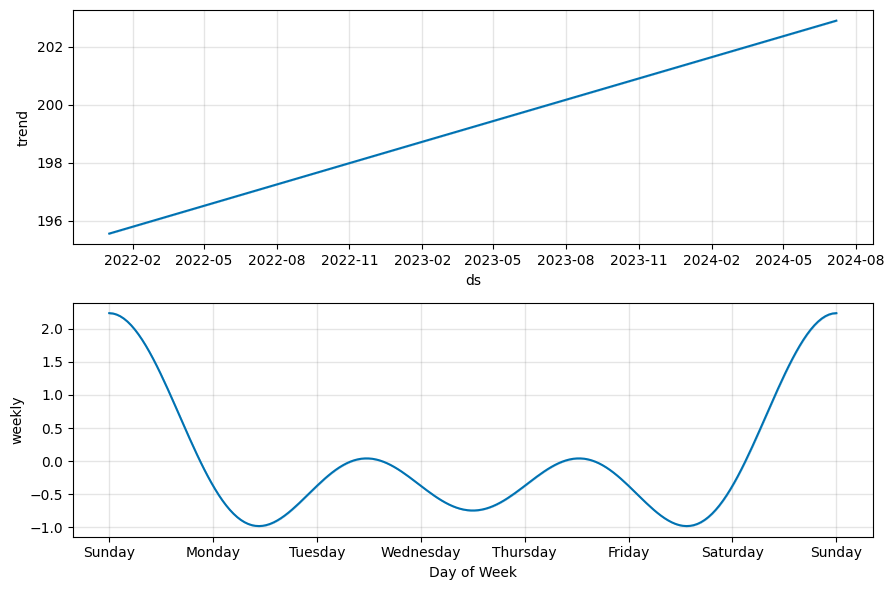

In [15]:

# Forecast Plot
fig1 = model.plot(forecast)
fig1.savefig('forecast_plot.png')

# Trend & Seasonality Components
fig2 = model.plot_components(forecast)
fig2.savefig('forecast_components.png')


Visualizations and ARIMA comparison completed.


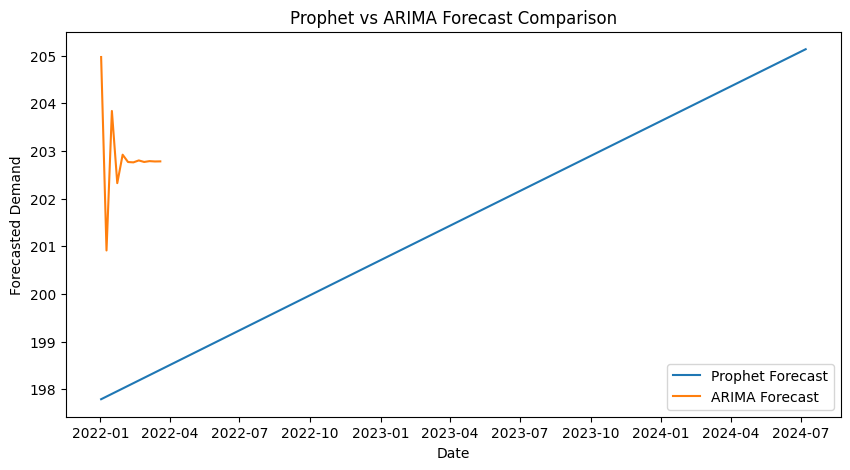

In [16]:
#ARIMA model
arima_model = ARIMA(df['y'], order=(2,1,2))
arima_result = arima_model.fit()


# ARIMA future forecast
arima_forecast = arima_result.forecast(steps=12)


# Combine Prophet vs ARIMA
comparison_df['arima_yhat'] = list(arima_forecast) + [None]*(len(comparison_df)-12)
comparison_df.to_csv('prophet_vs_arima_comparison.csv', index=False)


# Visualization: ARIMA vs Prophet
plt.figure(figsize=(10,5))
plt.plot(comparison_df['ds'], comparison_df['yhat'], label='Prophet Forecast')
plt.plot(comparison_df['ds'], comparison_df['arima_yhat'], label='ARIMA Forecast')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Forecasted Demand')
plt.title('Prophet vs ARIMA Forecast Comparison')
plt.savefig('prophet_vs_arima_plot.png')


print("Visualizations and ARIMA comparison completed.")